<a href="https://colab.research.google.com/github/krithi-ks/PetroVision/blob/main/notebooks/computer-vision/PetroVision_U-Net_BCE_Loss_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PetroVision — U-Net BCE Loss Experiment

## Experiment Information

**Project:** PetroVision

**Experiment ID:** CV-UNET-003

**Task:** Petroleum-related visible contamination segmentation

**Dataset:** LADOS

**Model:** Lightweight U-Net

**Experiment Type:** Controlled loss-function experiment

### Objective

This experiment evaluates a U-Net semantic segmentation model using Binary Cross-Entropy (BCE) loss.

The architecture, dataset, preprocessing, augmentation, optimizer, learning rate, batch size, number of epochs, and evaluation procedure are kept consistent with the previous U-Net experiments.

The purpose is to study the effect of the loss function while keeping the remaining experimental conditions unchanged.

### Comparison Experiments

- CV-UNET-001: BCE + Dice Loss
- CV-UNET-002: Dice Loss
- CV-UNET-003: BCE Loss

The results will be compared using IoU, Dice Score, Precision, Recall,
and Accuracy on the unseen LADOS test set.

No expected performance improvement is assumed before experimentation.

In [1]:
import os
import sys
import json
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cuda


## Project Setup

The experiment uses the existing PetroVision project source code and the dataset stored in Google Drive.

In [2]:
!git clone https://github.com/krithi-ks/PetroVision.git
%cd PetroVision

from pathlib import Path

print("Project root:", Path.cwd())
print("\nProject files:")
for item in sorted(Path(".").iterdir()):
    print(" -", item.name)

Cloning into 'PetroVision'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (196/196), done.
remote: Compressing objects: 100% (163/163), done.
remote: Total 196 (delta 65), reused 70 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (196/196), 8.52 MiB | 21.48 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/PetroVision
Project root: /content/PetroVision

Project files:
 - .git
 - .gitignore
 - README.md
 - app
 - data
 - docs
 - notebooks
 - references
 - reports
 - requirements.txt
 - results
 - src


In [3]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = "/content/PetroVision"
DRIVE_ROOT = "/content/drive/MyDrive/PetroVision"

assert os.path.isdir(PROJECT_ROOT)
assert os.path.isdir(os.path.join(PROJECT_ROOT, "src"))

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
print("Drive root:", DRIVE_ROOT)

Mounted at /content/drive
Project root: /content/PetroVision
Drive root: /content/drive/MyDrive/PetroVision


## Dataset Setup

The same LADOS dataset configuration used in the previous U-Net experiments is used here.

No dataset samples, labels, or experimental results are manually created.

In [5]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/PetroVision/datasets/"
    "PetroVision.v1i.png-mask-semantic.zip"
)

EXTRACT_DIR = Path("/content/PetroVision/data/lados")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:", EXTRACT_DIR)

Dataset extracted to: /content/PetroVision/data/lados


In [6]:
from src.vision.lados_dataset import LADOSDataset

DATASET_ROOT = os.path.join(
    PROJECT_ROOT,
    "data",
    "lados"
)

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16

train_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="train",
    image_size=IMAGE_SIZE,
    augment=True
)

val_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="valid",
    image_size=IMAGE_SIZE,
    augment=False
)

test_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="test",
    image_size=IMAGE_SIZE,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 2370
Validation samples: 675
Test samples: 343


## Model and BCE Loss

The U-Net architecture remains unchanged from the previous experiments.

Only the loss function is changed to Binary Cross-Entropy with logits.

In [7]:
from src.vision.unet import UNet

model = UNet(
    in_channels=3,
    out_channels=1
).to(DEVICE)

criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

EPOCHS = 20

print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Trainable parameters: 1942577
Loss: BCEWithLogitsLoss()
Optimizer: Adam


## Training

The model is trained using BCE loss.

The best checkpoint is selected using validation loss. Training history is saved so that later comparisons can be generated automatically without manually entering results.

In [8]:
checkpoint_dir = os.path.join(
    DRIVE_ROOT,
    "models"
)

results_dir = os.path.join(
    DRIVE_ROOT,
    "results",
    "cv_unet_003"
)

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

checkpoint_path = os.path.join(
    checkpoint_dir,
    "cv_unet_003_best.pt"
)

history_path = os.path.join(
    results_dir,
    "training_history.json"
)

best_val_loss = float("inf")
best_epoch = None

train_losses = []
validation_losses = []

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            masks
        )

        loss.backward()
        optimizer.step()

        running_train_loss += (
            loss.item() * images.size(0)
        )

    train_loss = (
        running_train_loss /
        len(train_loader.dataset)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(images)

            loss = criterion(
                logits,
                masks
            )

            running_val_loss += (
                loss.item() * images.size(0)
            )

    validation_loss = (
        running_val_loss /
        len(val_loader.dataset)
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {validation_loss:.6f}"
    )

    # -------------------------
    # Save best checkpoint
    # -------------------------
    if validation_loss < best_val_loss:

        best_val_loss = validation_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "experiment_id": "CV-UNET-003",
                "epoch": best_epoch,
                "validation_loss": best_val_loss,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
            },
            checkpoint_path
        )

history = {
    "train_loss": train_losses,
    "validation_loss": validation_losses
}

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Checkpoint:", checkpoint_path)
print("History:", history_path)

Epoch 01/20 | Train Loss: 0.602851 | Validation Loss: 0.581131
Epoch 02/20 | Train Loss: 0.582942 | Validation Loss: 0.567935
Epoch 03/20 | Train Loss: 0.570368 | Validation Loss: 0.568741
Epoch 04/20 | Train Loss: 0.563873 | Validation Loss: 0.545738
Epoch 05/20 | Train Loss: 0.557115 | Validation Loss: 0.563709
Epoch 06/20 | Train Loss: 0.547084 | Validation Loss: 0.616144
Epoch 07/20 | Train Loss: 0.553433 | Validation Loss: 0.534097
Epoch 08/20 | Train Loss: 0.543923 | Validation Loss: 0.575222
Epoch 09/20 | Train Loss: 0.540433 | Validation Loss: 0.543173
Epoch 10/20 | Train Loss: 0.523100 | Validation Loss: 0.543777
Epoch 11/20 | Train Loss: 0.507401 | Validation Loss: 0.506058
Epoch 12/20 | Train Loss: 0.501517 | Validation Loss: 0.515449
Epoch 13/20 | Train Loss: 0.489580 | Validation Loss: 0.583442
Epoch 14/20 | Train Loss: 0.487748 | Validation Loss: 0.520271
Epoch 15/20 | Train Loss: 0.484973 | Validation Loss: 0.491831
Epoch 16/20 | Train Loss: 0.474199 | Validation Loss: 0

## Training History

The following graph is generated directly from the recorded training history.

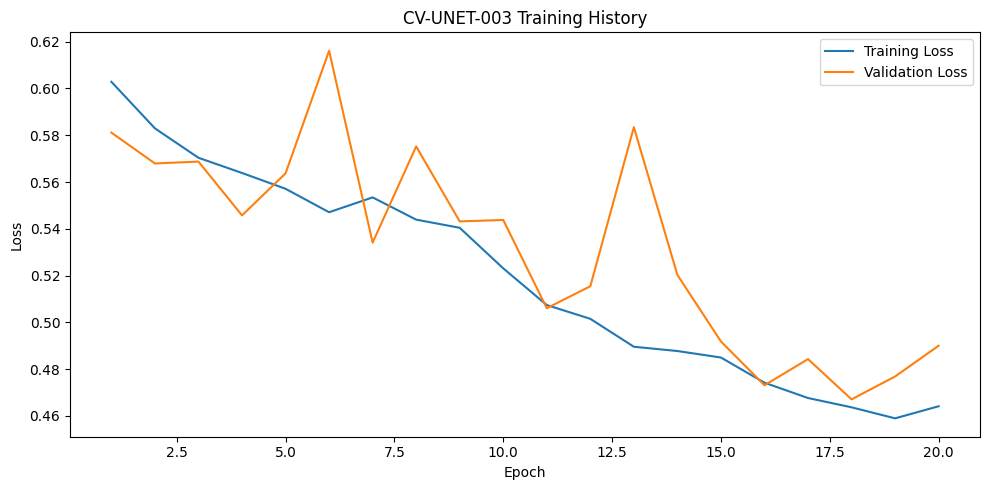

In [9]:
plt.figure(figsize=(10, 5))

epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.plot(
    epochs,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CV-UNET-003 Training History")
plt.legend()
plt.tight_layout()
plt.show()

## Test Evaluation

The best validation-loss checkpoint is evaluated on the held-out test set.

IoU, Dice, Precision, Recall, Accuracy, and pixel-level confusion components are calculated from the actual predictions.

In [10]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

TP = 0
FP = 0
FN = 0
TN = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(images)

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        )

        targets = (
            masks >= 0.5
        )

        TP += torch.logical_and(
            predictions,
            targets
        ).sum().item()

        FP += torch.logical_and(
            predictions,
            ~targets
        ).sum().item()

        FN += torch.logical_and(
            ~predictions,
            targets
        ).sum().item()

        TN += torch.logical_and(
            ~predictions,
            ~targets
        ).sum().item()


epsilon = 1e-8

iou = TP / (
    TP + FP + FN + epsilon
)

dice = (
    2 * TP
) / (
    2 * TP + FP + FN + epsilon
)

precision = TP / (
    TP + FP + epsilon
)

recall = TP / (
    TP + FN + epsilon
)

accuracy = (
    TP + TN
) / (
    TP + TN + FP + FN + epsilon
)

test_metrics = {
    "experiment_id": "CV-UNET-003",
    "best_epoch": checkpoint["epoch"],
    "validation_loss": checkpoint["validation_loss"],
    "IoU": iou,
    "Dice": dice,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "TP": TP,
    "FP": FP,
    "FN": FN,
    "TN": TN
}

for key, value in test_metrics.items():
    print(f"{key}: {value}")

experiment_id: CV-UNET-003
best_epoch: 18
validation_loss: 0.4670788948624222
IoU: 0.6517796060663091
Dice: 0.7891847116559495
Precision: 0.804083871046055
Recall: 0.7748276512893448
Accuracy: 0.7795861691844703
TP: 9273837
FP: 2259583
FN: 2695066
TN: 8250362


## Save Test Results

The calculated test metrics are saved as the authoritative output for CV-UNET-003.

These values will be used automatically in the later experiment comparison.

In [11]:
metrics_path = os.path.join(
    results_dir,
    "test_metrics.json"
)

with open(
    metrics_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        test_metrics,
        f,
        indent=2
    )

print("Saved:", metrics_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv_unet_003/test_metrics.json


## Test Metrics Visualization

The chart is generated directly from the calculated test metrics.

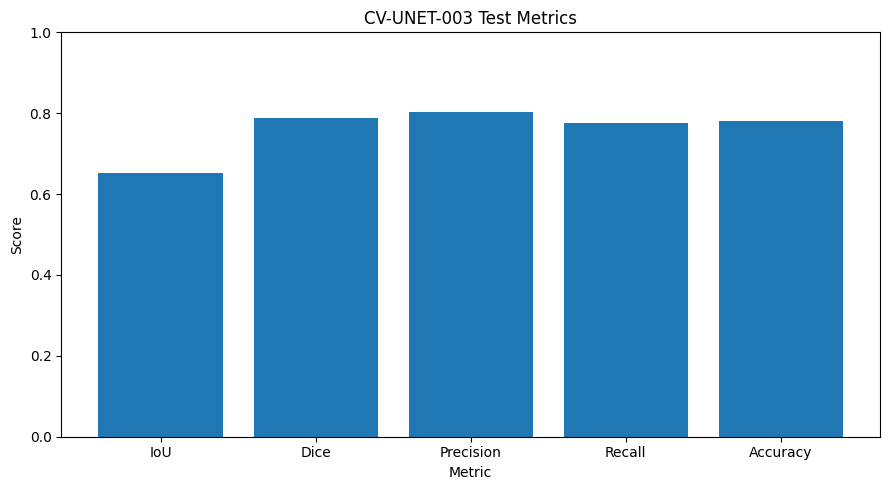

In [12]:
metric_names = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

metric_values = [
    test_metrics[name]
    for name in metric_names
]

plt.figure(figsize=(9, 5))

plt.bar(
    metric_names,
    metric_values
)

plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("CV-UNET-003 Test Metrics")

plt.tight_layout()
plt.show()

## Qualitative Test Predictions

The following examples show the original image, ground-truth petroleum mask, predicted mask, and prediction overlay.

The predictions are generated directly from the trained CV-UNET-003 checkpoint.

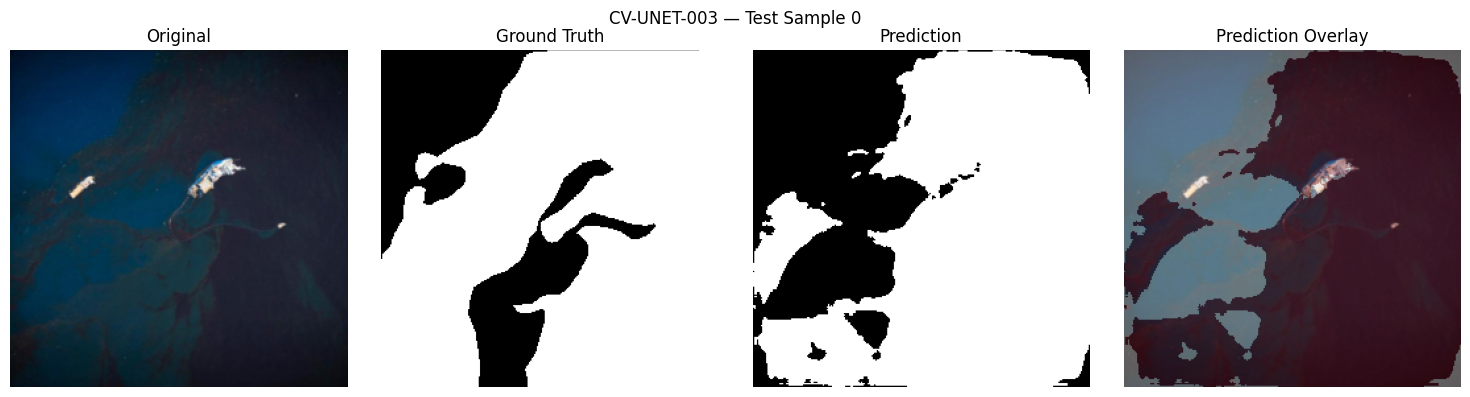

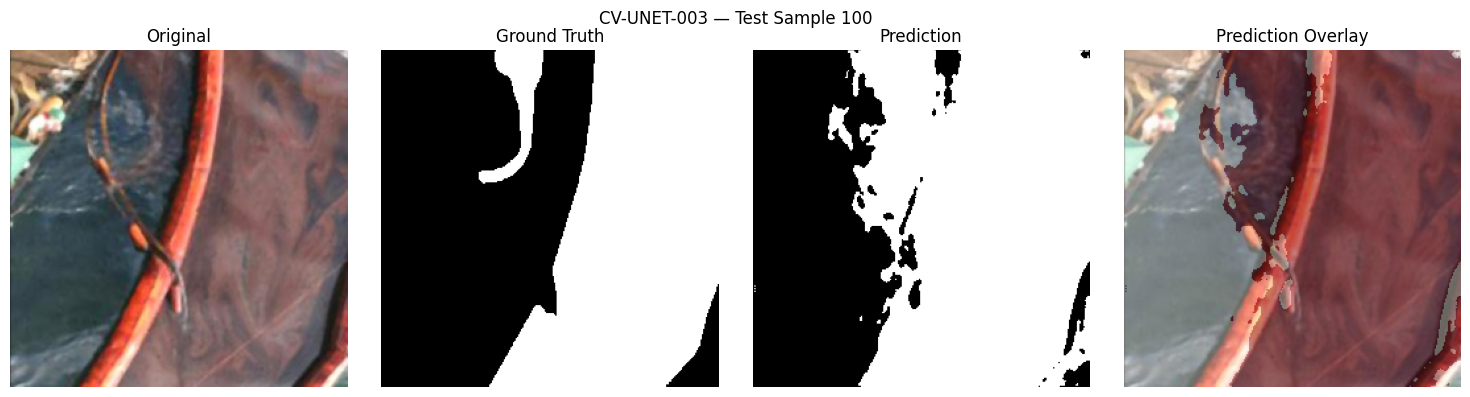

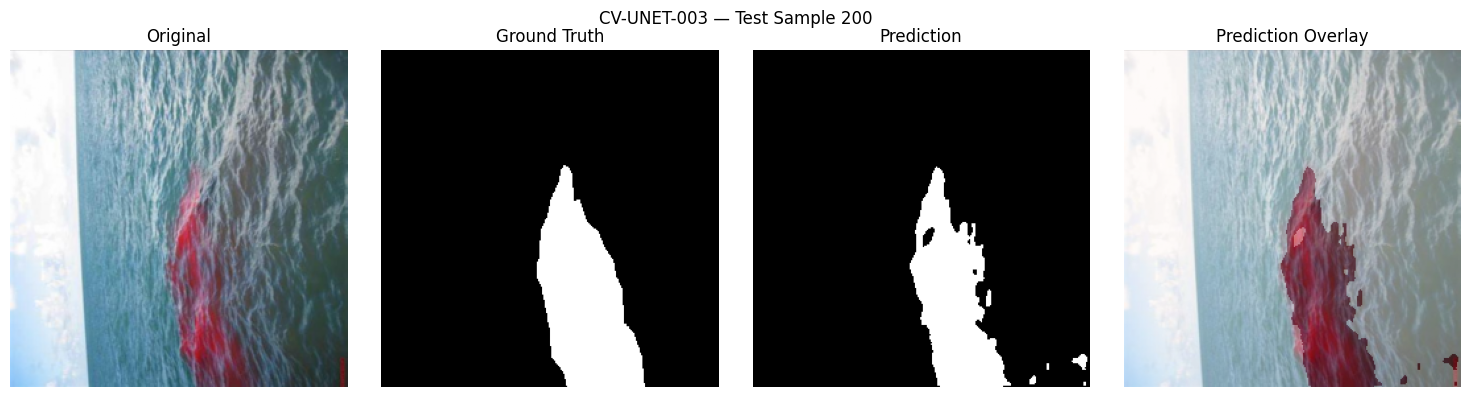

In [13]:
sample_indices = [
    0,
    100,
    200
]

for sample_index in sample_indices:

    image, mask = test_dataset[sample_index]

    image_batch = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        probability = torch.sigmoid(
            model(image_batch)
        )[0, 0].cpu().numpy()

    prediction = probability >= 0.5

    image_np = (
        image
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

    mask_np = (
        mask
        .squeeze()
        .cpu()
        .numpy()
        >= 0.5
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(15, 4)
    )

    axes[0].imshow(image_np)
    axes[0].set_title("Original")

    axes[1].imshow(
        mask_np,
        cmap="gray"
    )
    axes[1].set_title("Ground Truth")

    axes[2].imshow(
        prediction,
        cmap="gray"
    )
    axes[2].set_title("Prediction")

    axes[3].imshow(image_np)
    axes[3].imshow(
        prediction,
        alpha=0.35,
        cmap="Reds"
    )
    axes[3].set_title("Prediction Overlay")

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        f"CV-UNET-003 — Test Sample {sample_index}"
    )

    plt.tight_layout()
    plt.show()

## Pixel-Level Error Analysis

The distribution of true-positive, false-positive, false-negative, and true-negative pixels is visualized using the actual test predictions.

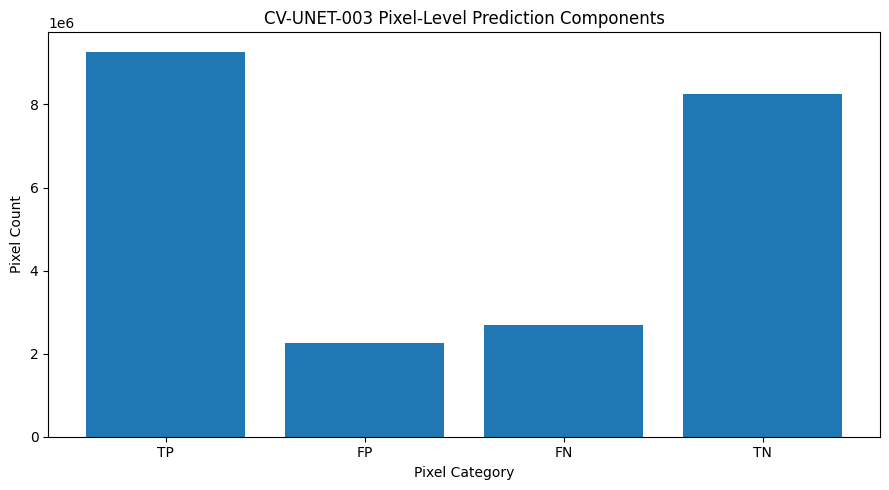

In [14]:
error_names = [
    "TP",
    "FP",
    "FN",
    "TN"
]

error_values = [
    test_metrics[name]
    for name in error_names
]

plt.figure(figsize=(9, 5))

plt.bar(
    error_names,
    error_values
)

plt.xlabel("Pixel Category")
plt.ylabel("Pixel Count")
plt.title("CV-UNET-003 Pixel-Level Prediction Components")

plt.tight_layout()
plt.show()

## Experiment Output Verification

The experiment files are checked to confirm that the model checkpoint, training history, and test metrics have been saved.

In [15]:
output_files = [
    checkpoint_path,
    history_path,
    metrics_path
]

for path in output_files:
    print(
        path,
        "->",
        os.path.exists(path)
    )

/content/drive/MyDrive/PetroVision/models/cv_unet_003_best.pt -> True
/content/drive/MyDrive/PetroVision/results/cv_unet_003/training_history.json -> True
/content/drive/MyDrive/PetroVision/results/cv_unet_003/test_metrics.json -> True


## Direct Comparison: CV-UNET-001 vs CV-UNET-003

This comparison evaluates BCE + Dice loss against BCE loss while
keeping the remaining experimental setup unchanged.

In [24]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DRIVE_ROOT = Path("/content/drive/MyDrive/PetroVision")

exp_001 = "cv_unet_001"
exp_003 = "cv_unet_003"

with open(DRIVE_ROOT / "results" / exp_001 / "test_metrics.json") as f:
    metrics_001 = json.load(f)

with open(DRIVE_ROOT / "results" / exp_003 / "test_metrics.json") as f:
    metrics_003 = json.load(f)

metrics = ["IoU", "Dice", "Precision", "Recall", "Accuracy"]

comparison_001_003 = pd.DataFrame({
    "Metric": metrics,
    "CV-UNET-001 (BCE + Dice)": [
        metrics_001[m] for m in metrics
    ],
    "CV-UNET-003 (BCE)": [
        metrics_003[m] for m in metrics
    ]
})

display(
    comparison_001_003.style.format({
        "CV-UNET-001 (BCE + Dice)": "{:.6f}",
        "CV-UNET-003 (BCE)": "{:.6f}"
    })
)

,Metric,CV-UNET-001 (BCE + Dice),CV-UNET-003 (BCE)
0,IoU,0.649758,0.651780
1,Dice,0.787701,0.789185
2,Precision,0.766569,0.804084
3,Recall,0.810031,0.774828
4,Accuracy,0.767513,0.779586


In [25]:
difference_001_003 = pd.DataFrame({
    "Metric": metrics,
    "CV-UNET-003 minus CV-UNET-001": [
        metrics_003[m] - metrics_001[m]
        for m in metrics
    ]
})

display(
    difference_001_003.style.format({
        "CV-UNET-003 minus CV-UNET-001": "{:+.6f}"
    })
)

,Metric,CV-UNET-003 minus CV-UNET-001
0,IoU,+0.002022
1,Dice,+0.001484
2,Precision,+0.037515
3,Recall,-0.035203
4,Accuracy,+0.012073


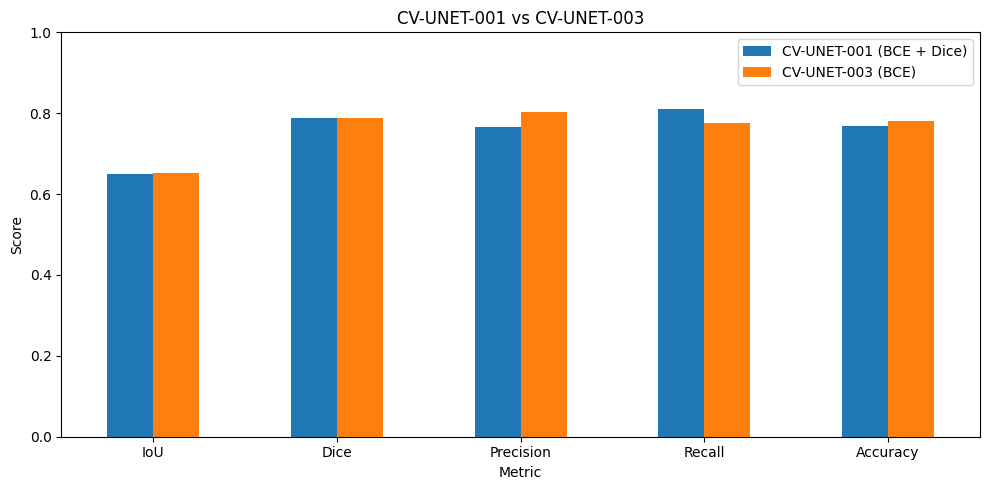

In [26]:
chart_df = comparison_001_003.set_index("Metric")

ax = chart_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("CV-UNET-001 vs CV-UNET-003")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Direct Comparison: CV-UNET-002 vs CV-UNET-003

This comparison evaluates Dice loss against BCE loss while
keeping the remaining experimental setup unchanged.

In [27]:
exp_002 = "cv_unet_002"

with open(DRIVE_ROOT / "results" / exp_002 / "test_metrics.json") as f:
    metrics_002 = json.load(f)

comparison_002_003 = pd.DataFrame({
    "Metric": metrics,
    "CV-UNET-002 (Dice)": [
        metrics_002[m] for m in metrics
    ],
    "CV-UNET-003 (BCE)": [
        metrics_003[m] for m in metrics
    ]
})

display(
    comparison_002_003.style.format({
        "CV-UNET-002 (Dice)": "{:.6f}",
        "CV-UNET-003 (BCE)": "{:.6f}"
    })
)

,Metric,CV-UNET-002 (Dice),CV-UNET-003 (BCE)
0,IoU,0.637756,0.651780
1,Dice,0.778817,0.789185
2,Precision,0.723926,0.804084
3,Recall,0.842715,0.774828
4,Accuracy,0.745137,0.779586


In [28]:
difference_002_003 = pd.DataFrame({
    "Metric": metrics,
    "CV-UNET-003 minus CV-UNET-002": [
        metrics_003[m] - metrics_002[m]
        for m in metrics
    ]
})

display(
    difference_002_003.style.format({
        "CV-UNET-003 minus CV-UNET-002": "{:+.6f}"
    })
)

,Metric,CV-UNET-003 minus CV-UNET-002
0,IoU,+0.014023
1,Dice,+0.010368
2,Precision,+0.080158
3,Recall,-0.067887
4,Accuracy,+0.034450


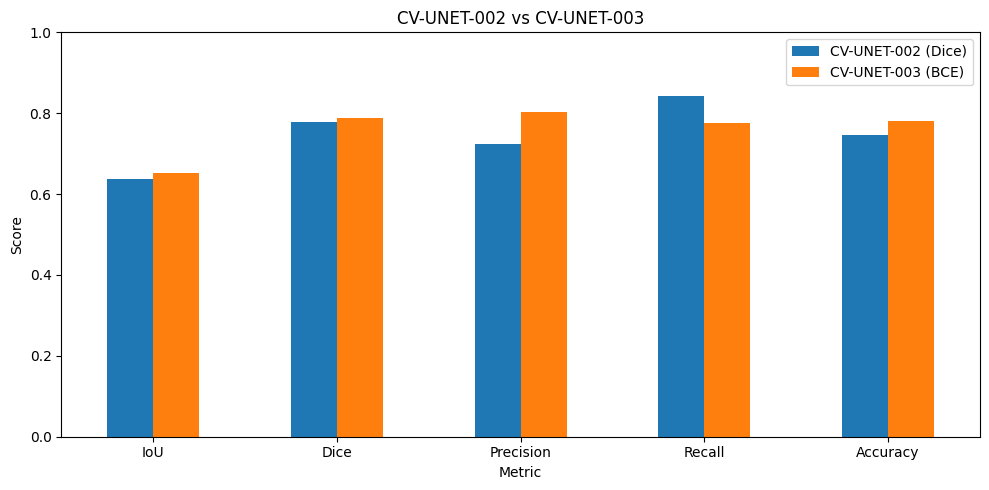

In [29]:
chart_df = comparison_002_003.set_index("Metric")

ax = chart_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("CV-UNET-002 vs CV-UNET-003")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Comparison with CV-UNET-001 and CV-UNET-002

This section compares the three U-Net loss-function experiments using
their saved test metrics and training histories.

The comparison is generated directly from the experiment output files.

In [16]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DRIVE_ROOT = Path("/content/drive/MyDrive/PetroVision")

experiment_ids = [
    "cv_unet_001",
    "cv_unet_002",
    "cv_unet_003"
]

loss_names = {
    "cv_unet_001": "BCE + Dice",
    "cv_unet_002": "Dice",
    "cv_unet_003": "BCE"
}

comparison_metrics = {}
comparison_histories = {}

for experiment_id in experiment_ids:
    metrics_path = DRIVE_ROOT / "results" / experiment_id / "test_metrics.json"
    history_path = DRIVE_ROOT / "results" / experiment_id / "training_history.json"

    with open(metrics_path, "r") as f:
        comparison_metrics[experiment_id] = json.load(f)

    with open(history_path, "r") as f:
        comparison_histories[experiment_id] = json.load(f)

print("Loaded experiments:")
for experiment_id in experiment_ids:
    print(f"- {experiment_id}")

Loaded experiments:
- cv_unet_001
- cv_unet_002
- cv_unet_003


In [17]:
metric_names = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

comparison_table = []

for experiment_id in experiment_ids:
    row = {
        "Experiment": experiment_id.upper(),
        "Loss": loss_names[experiment_id]
    }

    for metric in metric_names:
        row[metric] = comparison_metrics[experiment_id][metric]

    comparison_table.append(row)

comparison_df = pd.DataFrame(comparison_table)

display(
    comparison_df.style.format({
        "IoU": "{:.6f}",
        "Dice": "{:.6f}",
        "Precision": "{:.6f}",
        "Recall": "{:.6f}",
        "Accuracy": "{:.6f}"
    })
)

,Experiment,Loss,IoU,Dice,Precision,Recall,Accuracy
0,CV_UNET_001,BCE + Dice,0.649758,0.787701,0.766569,0.810031,0.767513
1,CV_UNET_002,Dice,0.637756,0.778817,0.723926,0.842715,0.745137
2,CV_UNET_003,BCE,0.651780,0.789185,0.804084,0.774828,0.779586


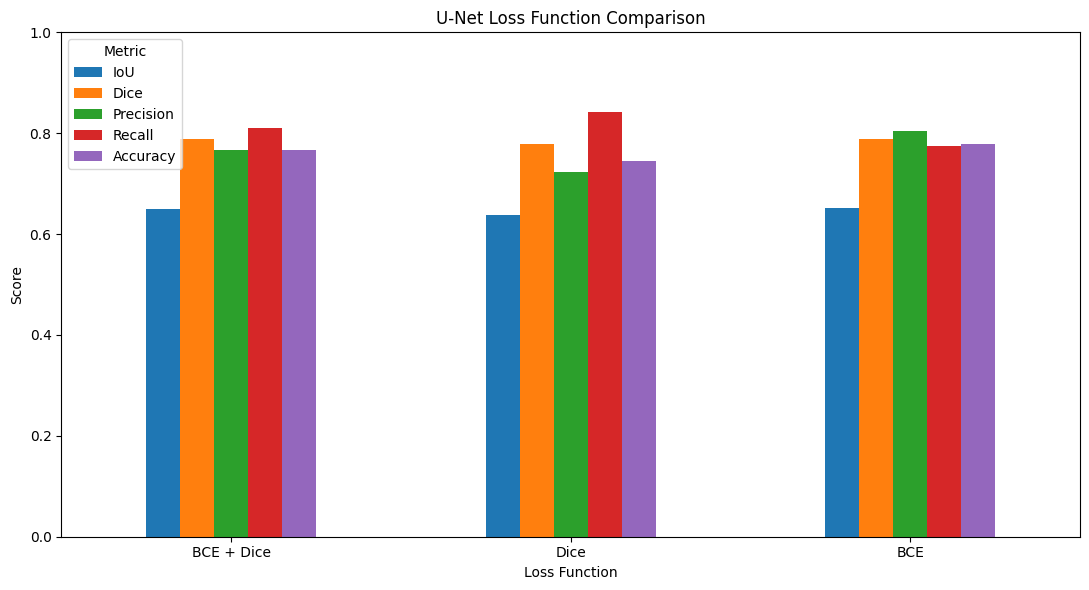

In [18]:
plot_df = comparison_df.set_index("Loss")[metric_names]

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_xlabel("Loss Function")
ax.set_ylabel("Score")
ax.set_title("U-Net Loss Function Comparison")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

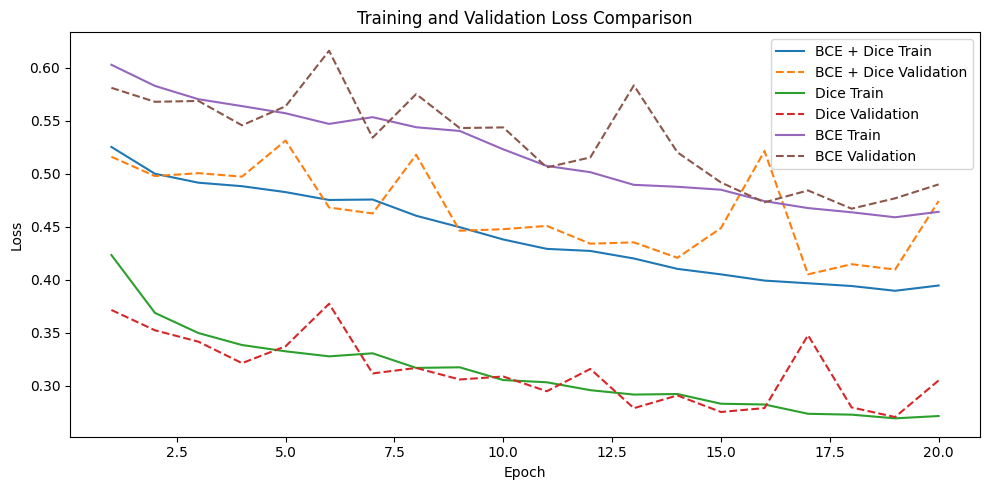

In [19]:
plt.figure(figsize=(10, 5))

for experiment_id in experiment_ids:
    history = comparison_histories[experiment_id]

    train_loss = history["train_loss"]
    validation_loss = history["validation_loss"]

    train_epochs = range(1, len(train_loss) + 1)
    validation_epochs = range(1, len(validation_loss) + 1)

    plt.plot(
        train_epochs,
        train_loss,
        label=f"{loss_names[experiment_id]} Train"
    )

    plt.plot(
        validation_epochs,
        validation_loss,
        linestyle="--",
        label=f"{loss_names[experiment_id]} Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
error_names = ["TP", "FP", "FN", "TN"]

error_rows = []

for experiment_id in experiment_ids:
    error_rows.append({
        "Experiment": experiment_id.upper(),
        "Loss": loss_names[experiment_id],
        "TP": comparison_metrics[experiment_id]["TP"],
        "FP": comparison_metrics[experiment_id]["FP"],
        "FN": comparison_metrics[experiment_id]["FN"],
        "TN": comparison_metrics[experiment_id]["TN"]
    })

error_df = pd.DataFrame(error_rows)

display(error_df)

,Experiment,Loss,TP,FP,FN,TN
0,CV_UNET_001,BCE + Dice,9695181,2952318,2273722,7557627
1,CV_UNET_002,Dice,10086374,3846506,1882529,6663439
2,CV_UNET_003,BCE,9273837,2259583,2695066,8250362


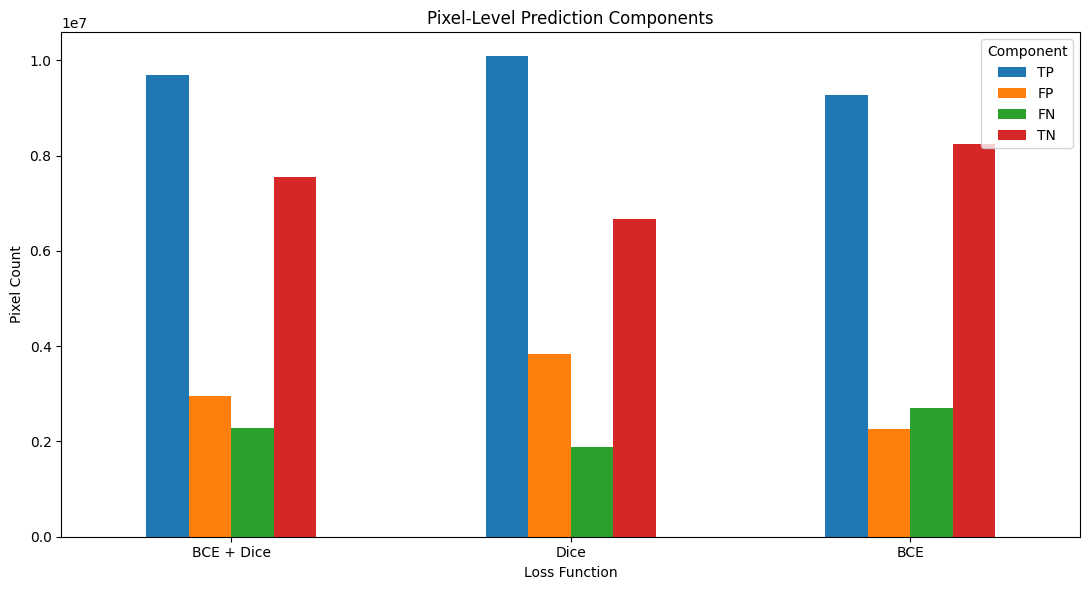

In [21]:
plot_errors = error_df.set_index("Loss")[error_names]

ax = plot_errors.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_xlabel("Loss Function")
ax.set_ylabel("Pixel Count")
ax.set_title("Pixel-Level Prediction Components")
plt.xticks(rotation=0)
plt.legend(title="Component")
plt.tight_layout()
plt.show()

In [22]:
baseline_id = "cv_unet_001"

difference_rows = []

for experiment_id in experiment_ids[1:]:
    row = {
        "Comparison": f"{experiment_id.upper()} vs {baseline_id.upper()}"
    }

    for metric in metric_names:
        row[metric] = (
            comparison_metrics[experiment_id][metric]
            - comparison_metrics[baseline_id][metric]
        )

    difference_rows.append(row)

difference_df = pd.DataFrame(difference_rows)

display(
    difference_df.style.format({
        "IoU": "{:+.6f}",
        "Dice": "{:+.6f}",
        "Precision": "{:+.6f}",
        "Recall": "{:+.6f}",
        "Accuracy": "{:+.6f}"
    })
)

,Comparison,IoU,Dice,Precision,Recall,Accuracy
0,CV_UNET_002 vs CV_UNET_001,-0.012002,-0.008884,-0.042643,+0.032684,-0.022376
1,CV_UNET_003 vs CV_UNET_001,+0.002022,+0.001484,+0.037515,-0.035203,+0.012073


In [23]:
best_by_metric = {}

for metric in metric_names:
    best_id = max(
        experiment_ids,
        key=lambda exp: comparison_metrics[exp][metric]
    )
    best_by_metric[metric] = {
        "experiment": best_id.upper(),
        "loss": loss_names[best_id],
        "value": comparison_metrics[best_id][metric]
    }

print("Metric-wise results generated from saved experiment outputs:\n")

for metric, result in best_by_metric.items():
    print(
        f"{metric}: {result['loss']} "
        f"({result['value']:.6f})"
    )

Metric-wise results generated from saved experiment outputs:

IoU: BCE (0.651780)
Dice: BCE (0.789185)
Precision: BCE (0.804084)
Recall: Dice (0.842715)
Accuracy: BCE (0.779586)
